# SimpleScatterPlot

Quick usage example.


# 00 - Import CSV with All Data
**The CSV is expected to be in this format**
- ID and absolute paths to niftis are critical
```
+-----+----------------------------+--------------+--------------+--------------+
| ID  | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

In [1]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/cognition_2023/metadata/master_list_proper_subjects.csv'
sheet = None

In [2]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=None, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_data()
data_df

,subject,Age,Hippocampus_GM_Vol,Parahippocampal_Gyrus_GM_Vol,Entorhinal_Cortex_GM_Vol,Normalized_Percent_Cognitive_Improvement,Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group,Z_Scored_Percent_Cognitive_Improvement,Percent_Cognitive_Improvement,Z_Scored_Subiculum_T_By_Origin_Group_,...,DECLINE,Cognitive_Improve,Z_Scored_Cognitive_Baseline,Z_Scored_Cognitive_Baseline__Lower_is_Better_,Min_Max_Normalized_Baseline,MinMaxNormBaseline_Higher_is_Better,ROI_to_Alz_Max,ROI_to_PD_Max,Standardzied_AD_Max,Standardized_PD_Max
0,101,62.0,5.8883,4.5970,2.4587,-0.392857,0.314066,0.314066,-21.428571,-1.282630,...,True,No,1.518764,-1.518764,0.72,0.28,12.222658,14.493929,-1.714513,-1.227368
1,102,77.0,3.7634,3.9036,2.2905,-0.666667,0.013999,0.013999,-36.363636,-1.760917,...,True,No,0.465551,-0.465551,0.48,0.52,14.020048,15.257338,-1.155843,-1.022243
2,103,76.0,4.8575,4.8177,3.1596,-1.447368,-0.841572,-0.841572,-78.947368,-0.595369,...,True,No,-0.061056,0.061056,0.36,0.64,15.118727,17.376384,-0.814348,-0.452865
3,104,65.0,4.8569,4.8655,2.6641,-2.372549,-1.855477,-1.855477,-129.411765,-0.945206,...,True,No,-0.412127,0.412127,0.28,0.72,13.112424,15.287916,-1.437954,-1.014027
4,105,50.0,5.9636,4.8434,3.3463,-0.192982,0.533109,0.533109,-10.526316,-1.151973,...,False,No,-0.061056,0.061056,0.36,0.64,15.086568,12.951426,-0.824344,-1.641831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,211,58.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.416000,...,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,152,69.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.701000,...,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
197,208,79.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.930000,...,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198,223,71.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.830000,...,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 01 - Preprocess Your Data

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [3]:
print(data_df.columns.tolist())

['subject', 'Age', 'Hippocampus_GM_Vol', 'Parahippocampal_Gyrus_GM_Vol', 'Entorhinal_Cortex_GM_Vol', 'Normalized_Percent_Cognitive_Improvement', 'Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group', 'Z_Scored_Percent_Cognitive_Improvement', 'Percent_Cognitive_Improvement', 'Z_Scored_Subiculum_T_By_Origin_Group_', 'Z_Scored_Subiculum_Connectivity_T', 'Subiculum_Connectivity_T_Redone', 'Subiculum_Connectivity_T', 'Amnesia_Lesion_T_Map', 'Memory_Network_T', 'Z_Scored_Memory_Network_R', 'Memory_Network_R', 'Subiculum_Grey_Matter', 'Subiculum_White_Matter', 'Subiculum_CSF', 'Subiculum_Total', 'Standardized_Age', 'Standardized_Percent_Improvement', 'Standardized_Subiculum_Connectivity', 'Standardized_Subiculum_Grey_Matter', 'Standardized_Subiculum_White_Matter', 'Standardized_Subiculum_CSF', 'Standardized_Subiculum_Total', 'Disease', 'Cohort', 'City', 'Inclusion_Cohort', 'Categorical_Age_Group', 'Age_Group', 'Age_And_Disease', 'Age_Disease_and_Cohort', 'Age_Disease_Cohort_Stim', 'Age_And

In [4]:
drop_list = ['Hippocampus_GM_Vol', 'Age']

In [5]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(data_df)

,subject,Age,Hippocampus_GM_Vol,Parahippocampal_Gyrus_GM_Vol,Entorhinal_Cortex_GM_Vol,Normalized_Percent_Cognitive_Improvement,Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group,Z_Scored_Percent_Cognitive_Improvement,Percent_Cognitive_Improvement,Z_Scored_Subiculum_T_By_Origin_Group_,...,DECLINE,Cognitive_Improve,Z_Scored_Cognitive_Baseline,Z_Scored_Cognitive_Baseline__Lower_is_Better_,Min_Max_Normalized_Baseline,MinMaxNormBaseline_Higher_is_Better,ROI_to_Alz_Max,ROI_to_PD_Max,Standardzied_AD_Max,Standardized_PD_Max
0,101,62.0,5.8883,4.5970,2.4587,-0.392857,0.314066,0.314066,-21.428571,-1.282630,...,True,No,1.518764,-1.518764,0.720,0.280,12.222658,14.493929,-1.714513,-1.227368
1,102,77.0,3.7634,3.9036,2.2905,-0.666667,0.013999,0.013999,-36.363636,-1.760917,...,True,No,0.465551,-0.465551,0.480,0.520,14.020048,15.257338,-1.155843,-1.022243
2,103,76.0,4.8575,4.8177,3.1596,-1.447368,-0.841572,-0.841572,-78.947368,-0.595369,...,True,No,-0.061056,0.061056,0.360,0.640,15.118727,17.376384,-0.814348,-0.452865
3,104,65.0,4.8569,4.8655,2.6641,-2.372549,-1.855477,-1.855477,-129.411765,-0.945206,...,True,No,-0.412127,0.412127,0.280,0.720,13.112424,15.287916,-1.437954,-1.014027
4,105,50.0,5.9636,4.8434,3.3463,-0.192982,0.533109,0.533109,-10.526316,-1.151973,...,False,No,-0.061056,0.061056,0.360,0.640,15.086568,12.951426,-0.824344,-1.641831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,30,58.0,7.1449,6.5446,3.8850,-0.638889,0.106772,0.106772,-1.388889,-0.590767,...,False,No,1.114522,1.114522,1.000,1.000,13.873339,15.685024,-0.347959,-0.150172
69,31,64.0,0.0067,0.0478,0.0376,0.666667,1.086636,1.086636,1.449275,-1.065220,...,False,Yes,-1.345113,-1.345113,0.250,0.250,10.930371,11.599140,-0.855211,-0.712879
70,33,60.0,8.5035,7.4388,4.5143,-0.643357,0.103418,0.103418,-1.398601,-1.108473,...,False,No,0.704583,0.704583,0.875,0.875,6.780175,8.774895,-1.570542,-1.101833
72,36,52.0,8.2357,7.1067,4.5170,-1.286713,-0.379443,-0.379443,-2.797203,-0.775406,...,False,No,0.704583,0.704583,0.875,0.875,9.841726,16.308768,-1.042851,-0.064270


**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

In [6]:
data_df.columns

Index(['subject', 'Age', 'Hippocampus_GM_Vol', 'Parahippocampal_Gyrus_GM_Vol',
       'Entorhinal_Cortex_GM_Vol', 'Normalized_Percent_Cognitive_Improvement',
       'Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group',
       'Z_Scored_Percent_Cognitive_Improvement',
       'Percent_Cognitive_Improvement',
       'Z_Scored_Subiculum_T_By_Origin_Group_',
       'Z_Scored_Subiculum_Connectivity_T', 'Subiculum_Connectivity_T_Redone',
       'Subiculum_Connectivity_T', 'Amnesia_Lesion_T_Map', 'Memory_Network_T',
       'Z_Scored_Memory_Network_R', 'Memory_Network_R',
       'Subiculum_Grey_Matter', 'Subiculum_White_Matter', 'Subiculum_CSF',
       'Subiculum_Total', 'Standardized_Age',
       'Standardized_Percent_Improvement',
       'Standardized_Subiculum_Connectivity',
       'Standardized_Subiculum_Grey_Matter',
       'Standardized_Subiculum_White_Matter', 'Standardized_Subiculum_CSF',
       'Standardized_Subiculum_Total', 'Disease', 'Cohort', 'City',
       'Inclusion_Cohort', 

Set the parameters for dropping rows

In [7]:
column = 'cluster_label'  # The column you'd like to evaluate
condition = 'equal'  # The condition to check ('equal', 'above', 'below', 'not')
value = -1 # The value to drop if found

In [ ]:
# data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
# display(data_df)

# Generate Scatterplot

<Figure size 432x432 with 0 Axes>

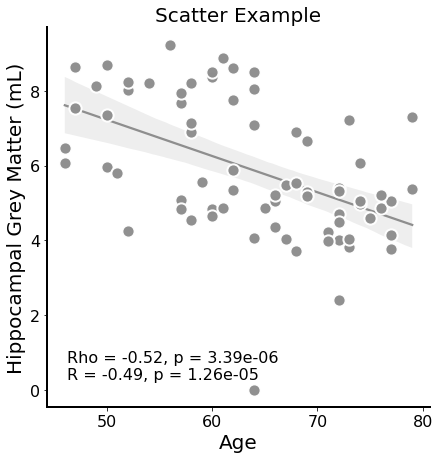

In [11]:
from calvin_utils.statistical_utils.scatterplot import simple_scatter
simple_scatter(
    data_df,
    x_col='Age',
    y_col='Hippocampus_GM_Vol',
    dataset_name='Scatter Example',
    out_dir='/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/cognition_2023/post-publication_analyses/age-to-hpc',
    x_label='Age',
    y_label='Hippocampal Grey Matter (mL)',
)